In [3]:
import json
import glob
import statistics
import collections
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [4]:
# ── CONFIGURE THESE PATHS ──────────────────────────────────────────────────
DETAIL_CSV_LOCAL  = r"eval_results_buas_Three_Models\eval_detail_20260519_194348.csv"
SUMMARY_CSV_LOCAL = r"eval_results_buas_Three_Models\eval_summary_20260519_194348.csv"
QUESTS_DIR_LOCAL  = r"eval_results_buas_Three_Models"

DETAIL_CSV_CLAUDE  = r"eval_results_buas_Claude\eval_detail_20260520_162414.csv"
SUMMARY_CSV_CLAUDE = r"eval_results_buas_Claude\eval_summary_20260520_162414.csv"
QUESTS_DIR_CLAUDE  = r"eval_results_buas_Claude"

DETAIL_CSV_SPEED  = r"eval_results_buas_Speed_Test\eval_detail_20260520_193804.csv"
SUMMARY_CSV_SPEED = r"eval_results_buas_Speed_Test\eval_summary_20260520_193804.csv"
QUESTS_DIR_SPEED  = r"eval_results_buas_Speed_Test"
# ───────────────────────────────────────────────────────────────────────────

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

detail  = pd.concat([pd.read_csv(DETAIL_CSV_LOCAL), pd.read_csv(DETAIL_CSV_CLAUDE), pd.read_csv(DETAIL_CSV_SPEED)], ignore_index=True)
summary = pd.concat([pd.read_csv(SUMMARY_CSV_LOCAL), pd.read_csv(SUMMARY_CSV_CLAUDE), pd.read_csv(SUMMARY_CSV_SPEED)], ignore_index=True)

qwen35_files = sorted(glob.glob(os.path.join(QUESTS_DIR_LOCAL, "quests_Qwen3.5*.json")))
qwen36_files = sorted(glob.glob(os.path.join(QUESTS_DIR_SPEED, "quests_Qwen3.6*.json")))
gpt_files    = sorted(glob.glob(os.path.join(QUESTS_DIR_LOCAL, "quests_GPT*.json")))
llama_files  = sorted(glob.glob(os.path.join(QUESTS_DIR_LOCAL, "quests_Llama*.json")))
claude_files = sorted(glob.glob(os.path.join(QUESTS_DIR_CLAUDE, "quests_claude*.json")))

print(f"Detail rows: {len(detail)}")
print(f"Summary rows: {len(summary)}")
print(f"Qwen3.5 quest files: {len(qwen35_files)}")
print(f"Qwen3.6 quest files: {len(qwen36_files)}")
print(f"GPT-OSS quest files: {len(gpt_files)}")
print(f"Llama quest files:   {len(llama_files)}")
print(f"Claude quest files:  {len(claude_files)}")
print(f"Models: {detail['model'].unique().tolist()}")

Detail rows: 180
Summary rows: 18
Qwen3.5 quest files: 10
Qwen3.6 quest files: 10
GPT-OSS quest files: 10
Llama quest files:   10
Claude quest files:  10
Models: ['Qwen3.5-122B', 'Qwen3.6-27B', 'GPT-OSS-120B', 'Llama3.3-70B', 'claude-opus-4-7']


# PART 1: QUANTITATIVE

In [5]:
numeric_cols = [c for c in detail.columns if c not in ('model', 'run', 'chapter_id')]

def model_stats(col):
    result = {}
    for m in models:
        vals = detail[detail['model'] == m][col].dropna().tolist()
        if vals:
            result[m] = {
                'mean': round(statistics.mean(vals), 3),
                'stdev': round(statistics.stdev(vals) if len(vals) > 1 else 0.0, 3)
            }
    return result

In [6]:
models = detail['model'].unique().tolist()

# Build header
col_w = 13
header = f"{'Metric':<30}"
for m in models:
    short = m.replace('Qwen3.5-122B', 'Qwen3.5').replace('Qwen3.6-27B', 'Qwen3.6') \
             .replace('GPT-OSS-120B', 'GPT-OSS').replace('Llama3.3-70B', 'Llama3.3')
    header += f" {short+' mean':>{col_w}} {short+' stdev':>{col_w}}"
print(header)
print("-" * (30 + len(models) * (col_w * 2 + 2)))

for col in numeric_cols:
    s = model_stats(col)
    row = f"{col:<30}"
    for m in models:
        stats = s.get(m, {})
        row += f" {stats.get('mean', ''):>{col_w}} {stats.get('stdev', ''):>{col_w}}"
    print(row)

Metric                          Qwen3.5 mean Qwen3.5 stdev  Qwen3.6 mean Qwen3.6 stdev  GPT-OSS mean GPT-OSS stdev Llama3.3 mean Llama3.3 stdev claude-opus-4-7 mean claude-opus-4-7 stdev
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
json_parse_success                         1           0.0             1           0.0             1           0.0             1           0.0             1           0.0
attempts                                   1           0.0             1           0.0             1           0.0         1.167         0.461         1.033         0.183
generation_time_s                     20.589          7.26        53.002        27.535        13.994         3.521        45.939        27.599        52.525         8.878
input_tokens                        8564.967         8.045        8560.1         8.934      7899.467         5.987        9209.2 

# VISUALS FOR THE PAPER 

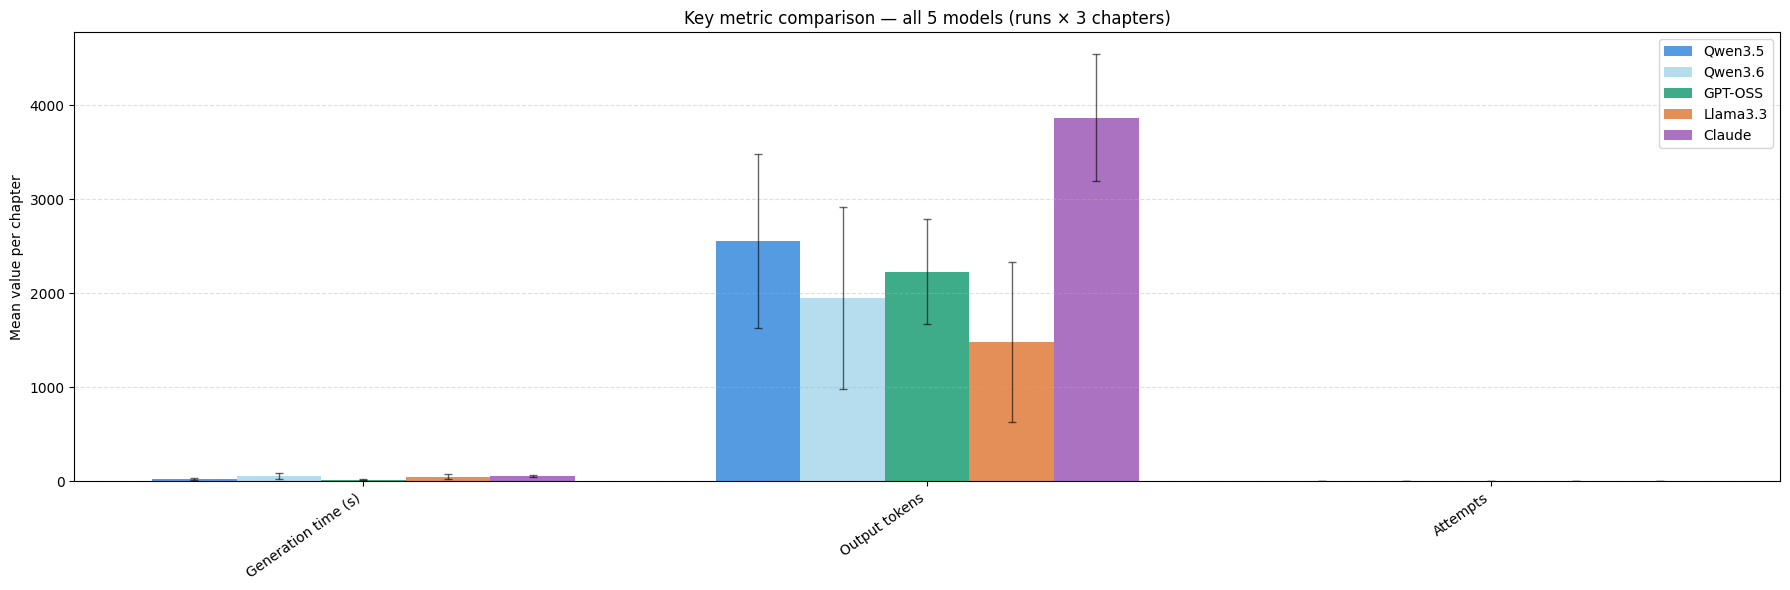

Saved → metric_comparison.png


In [7]:
metrics_to_plot = [
    ("generation_time_s", "Generation time (s)"),
    ("output_tokens",     "Output tokens"),
    ("attempts",          "Attempts"),
]

models_plot = [
    ("Qwen3.5-122B",   "Qwen3.5"),
    ("Qwen3.6-27B",    "Qwen3.6"),
    ("GPT-OSS-120B",   "GPT-OSS"),
    ("Llama3.3-70B",   "Llama3.3"),
    ("claude-opus-4-7","Claude"),
]

COLORS = {
    "Qwen3.5-122B":    "#378ADD",
    "Qwen3.6-27B":     "#A8D8EA",
    "GPT-OSS-120B":    "#1D9E75",
    "Llama3.3-70B":    "#E07B39",
    "claude-opus-4-7": "#9B59B6",
}

x = np.arange(len(metrics_to_plot))
n = len(models_plot)
width = 0.15  # 5 bars → narrower

fig, ax = plt.subplots(figsize=(18, 6))

for i, (model_id, model_label) in enumerate(models_plot):
    stats = model_stats.__func__ if hasattr(model_stats, '__func__') else model_stats
    means  = [model_stats(m).get(model_id, {}).get('mean',  0) for m, _ in metrics_to_plot]
    stdevs = [model_stats(m).get(model_id, {}).get('stdev', 0) for m, _ in metrics_to_plot]
    offset = (i - (n - 1) / 2) * width
    ax.bar(x + offset, means, width, label=model_label,
           color=COLORS[model_id], alpha=0.85, yerr=stdevs,
           capsize=3, error_kw={"elinewidth": 1, "alpha": 0.6})

ax.set_xticks(x)
ax.set_xticklabels([label for _, label in metrics_to_plot], rotation=35, ha='right', fontsize=10)
ax.set_ylabel("Mean value per chapter")
ax.set_title("Key metric comparison — all 5 models (runs × 3 chapters)")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150)
plt.show()
print("Saved → metric_comparison.png")

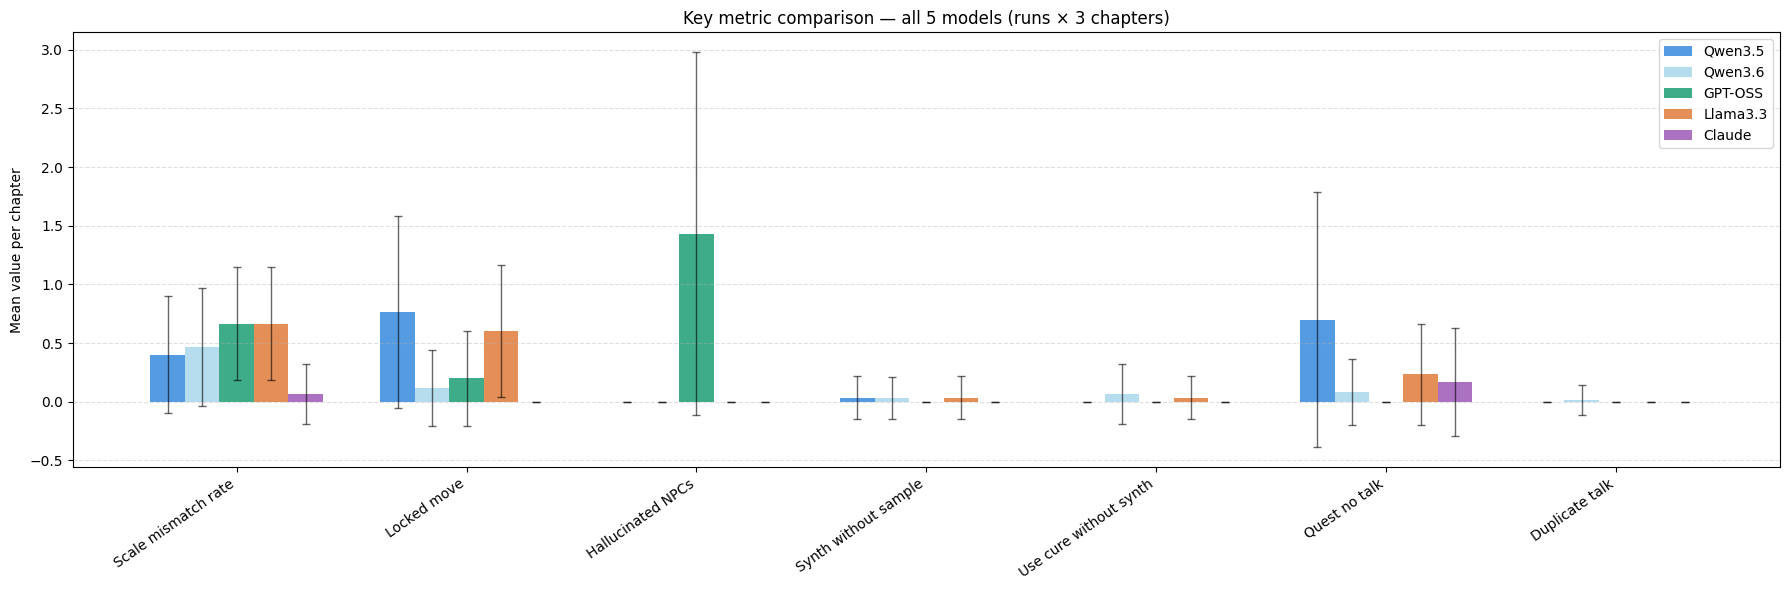

Saved → metric_comparison.png


In [8]:
metrics_to_plot = [
    ("scale_mismatch",        "Scale mismatch rate"),
    ("locked_move",           "Locked move"),
    ("hallucinated_npcs",     "Hallucinated NPCs"),
    ("synth_no_sample",       "Synth without sample"),
    ("use_cure_no_synth",     "Use cure without synth"),
    ("quest_no_talk",         "Quest no talk"),
    ("duplicate_talk",        "Duplicate talk"),
]

models_plot = [
    ("Qwen3.5-122B",   "Qwen3.5"),
    ("Qwen3.6-27B",    "Qwen3.6"),
    ("GPT-OSS-120B",   "GPT-OSS"),
    ("Llama3.3-70B",   "Llama3.3"),
    ("claude-opus-4-7","Claude"),
]

COLORS = {
    "Qwen3.5-122B":    "#378ADD",
    "Qwen3.6-27B":     "#A8D8EA",
    "GPT-OSS-120B":    "#1D9E75",
    "Llama3.3-70B":    "#E07B39",
    "claude-opus-4-7": "#9B59B6",
}

x = np.arange(len(metrics_to_plot))
n = len(models_plot)
width = 0.15  # 5 bars → narrower

fig, ax = plt.subplots(figsize=(18, 6))

for i, (model_id, model_label) in enumerate(models_plot):
    stats = model_stats.__func__ if hasattr(model_stats, '__func__') else model_stats
    means  = [model_stats(m).get(model_id, {}).get('mean',  0) for m, _ in metrics_to_plot]
    stdevs = [model_stats(m).get(model_id, {}).get('stdev', 0) for m, _ in metrics_to_plot]
    offset = (i - (n - 1) / 2) * width
    ax.bar(x + offset, means, width, label=model_label,
           color=COLORS[model_id], alpha=0.85, yerr=stdevs,
           capsize=3, error_kw={"elinewidth": 1, "alpha": 0.6})

ax.set_xticks(x)
ax.set_xticklabels([label for _, label in metrics_to_plot], rotation=35, ha='right', fontsize=10)
ax.set_ylabel("Mean value per chapter")
ax.set_title("Key metric comparison — all 5 models (runs × 3 chapters)")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150)
plt.show()
print("Saved → metric_comparison.png")

# BAR CHART: key metrics comparison

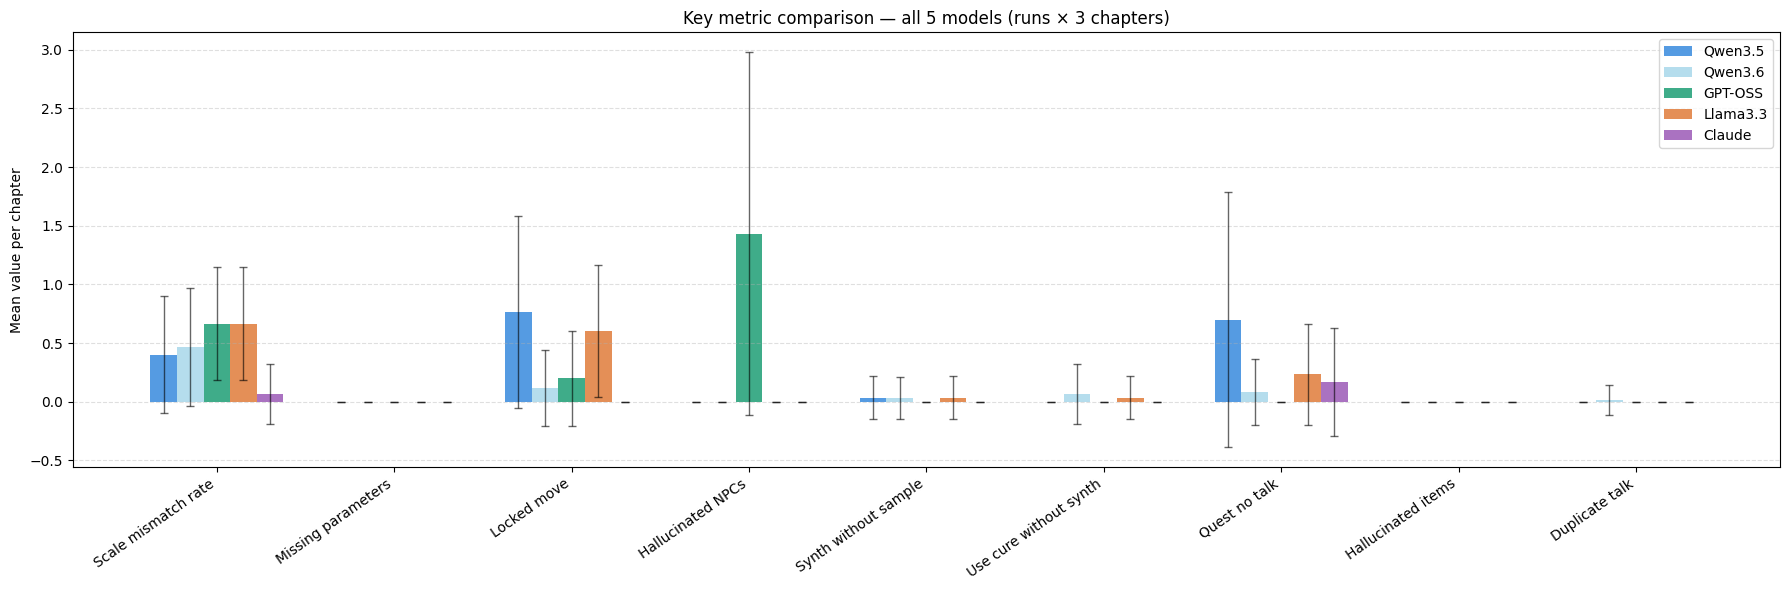

Saved → metric_comparison.png


In [9]:
metrics_to_plot = [
    ("scale_mismatch",        "Scale mismatch rate"),
    ("missing_parameters",    "Missing parameters"),
    ("locked_move",           "Locked move"),
    ("hallucinated_npcs",     "Hallucinated NPCs"),
    ("synth_no_sample",       "Synth without sample"),
    ("use_cure_no_synth",     "Use cure without synth"),
    ("quest_no_talk",         "Quest no talk"),
    ("hallucinated_items",    "Hallucinated items"),
    ("duplicate_talk",        "Duplicate talk"),
]

models_plot = [
    ("Qwen3.5-122B",   "Qwen3.5"),
    ("Qwen3.6-27B",    "Qwen3.6"),
    ("GPT-OSS-120B",   "GPT-OSS"),
    ("Llama3.3-70B",   "Llama3.3"),
    ("claude-opus-4-7","Claude"),
]

COLORS = {
    "Qwen3.5-122B":    "#378ADD",
    "Qwen3.6-27B":     "#A8D8EA",
    "GPT-OSS-120B":    "#1D9E75",
    "Llama3.3-70B":    "#E07B39",
    "claude-opus-4-7": "#9B59B6",
}

x = np.arange(len(metrics_to_plot))
n = len(models_plot)
width = 0.15  # 5 bars → narrower

fig, ax = plt.subplots(figsize=(18, 6))

for i, (model_id, model_label) in enumerate(models_plot):
    stats = model_stats.__func__ if hasattr(model_stats, '__func__') else model_stats
    means  = [model_stats(m).get(model_id, {}).get('mean',  0) for m, _ in metrics_to_plot]
    stdevs = [model_stats(m).get(model_id, {}).get('stdev', 0) for m, _ in metrics_to_plot]
    offset = (i - (n - 1) / 2) * width
    ax.bar(x + offset, means, width, label=model_label,
           color=COLORS[model_id], alpha=0.85, yerr=stdevs,
           capsize=3, error_kw={"elinewidth": 1, "alpha": 0.6})

ax.set_xticks(x)
ax.set_xticklabels([label for _, label in metrics_to_plot], rotation=35, ha='right', fontsize=10)
ax.set_ylabel("Mean value per chapter")
ax.set_title("Key metric comparison — all 5 models (runs × 3 chapters)")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150)
plt.show()
print("Saved → metric_comparison.png")

# PER-CHAPTER BREAKDOWN

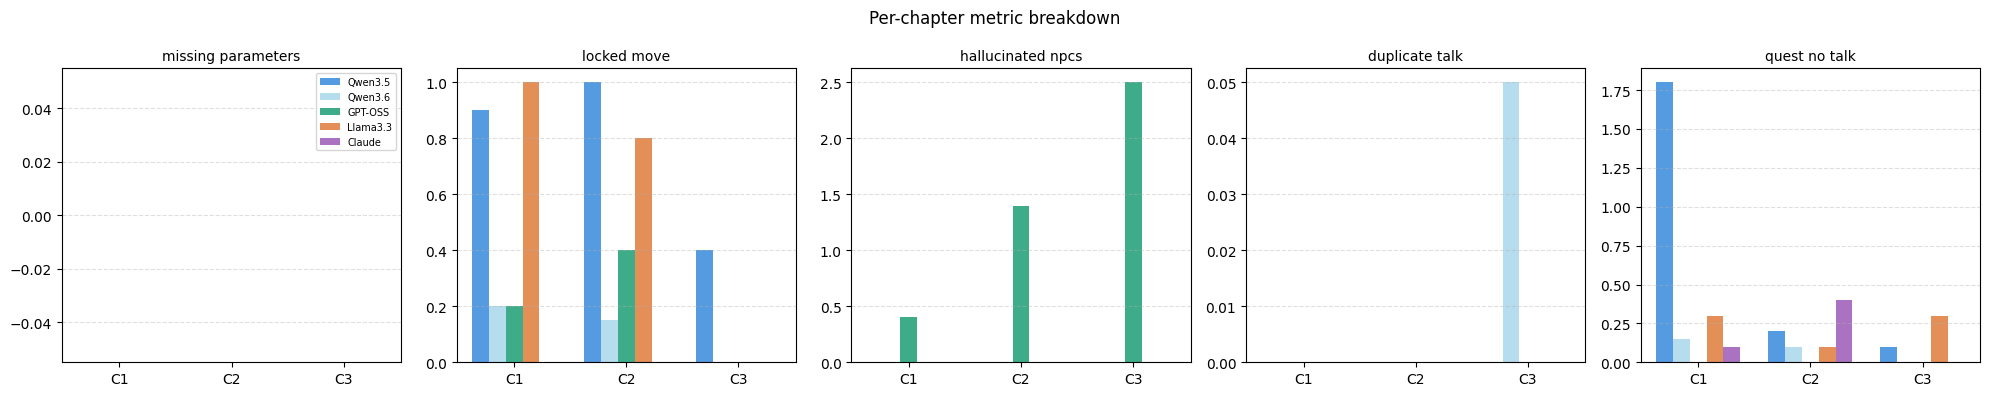

Saved → per_chapter_breakdown.png


In [10]:
chapter_metrics = ["missing_parameters", "locked_move", "hallucinated_npcs", "duplicate_talk", "quest_no_talk"]
chapters = ["C1", "C2", "C3"]

models_plot = [
    ("Qwen3.5-122B",    "Qwen3.5"),
    ("Qwen3.6-27B",     "Qwen3.6"),
    ("GPT-OSS-120B",    "GPT-OSS"),
    ("Llama3.3-70B",    "Llama3.3"),
    ("claude-opus-4-7", "Claude"),
]

n = len(models_plot)
width = 0.15
fig, axes = plt.subplots(1, len(chapter_metrics), figsize=(20, 4), sharey=False)

for ax, metric in zip(axes, chapter_metrics):
    for i, (model_id, model_label) in enumerate(models_plot):
        means = []
        for ch in chapters:
            vals = detail[(detail['model'] == model_id) & (detail['chapter_id'] == ch)][metric].tolist()
            means.append(round(statistics.mean(vals), 2) if vals else 0)
        x = np.arange(len(chapters))
        offset = (i - (n - 1) / 2) * width
        ax.bar(x + offset, means, width, label=model_label, color=COLORS[model_id], alpha=0.85)

    ax.set_title(metric.replace("_", " "), fontsize=10)
    ax.set_xticks(np.arange(len(chapters)))
    ax.set_xticklabels(chapters)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if ax == axes[0]:
        ax.legend(fontsize=7)

fig.suptitle("Per-chapter metric breakdown", fontsize=12)
plt.tight_layout()
plt.savefig("per_chapter_breakdown.png", dpi=150)
plt.show()
print("Saved → per_chapter_breakdown.png")

# Part 2 Qualitative 

In [11]:
def get_talk_steps(data):
    talks = []
    for entry in data:
        for quest in entry['quest_data'].get('quests', []):
            for step in quest.get('steps', []):
                if step.get('action') == 'TALK':
                    p = step.get('parameters', {})
                    target = (p.get('target') or step.get('target', '')).lower().strip()
                    dialogue = p.get('dialogue_content', [])
                    talks.append({
                        'run':     entry['run'],
                        'chapter': entry['chapter_id'],
                        'target':  target,
                        'n_lines': len(dialogue),
                        'lines':   dialogue,
                    })
    return talks

def get_titles(data):
    chapter_titles = [e['quest_data'].get('chapter_title', '') for e in data]
    quest_titles   = [q.get('quest_title', '')
                      for e in data
                      for q in e['quest_data'].get('quests', [])]
    return chapter_titles, quest_titles

all_model_data = {
    "Qwen3.5-122B":    [entry for f in qwen35_files  for entry in load_json(f)],
    "Qwen3.6-27B":     [entry for f in qwen36_files  for entry in load_json(f)],
    "GPT-OSS-120B":    [entry for f in gpt_files     for entry in load_json(f)],
    "Llama3.3-70B":    [entry for f in llama_files   for entry in load_json(f)],
    "claude-opus-4-7": [entry for f in claude_files  for entry in load_json(f)],
}

for model_id, data in all_model_data.items():
    talks = get_talk_steps(data)
    chapter_titles, quest_titles = get_titles(data)

    npc_counter  = collections.Counter(t['target'] for t in talks if t['target'])
    line_lengths = [t['n_lines'] for t in talks]
    unique_ct    = len(set(chapter_titles))
    unique_qt    = len(set(quest_titles))

    print(f"=== {model_id} ===")
    if not talks:
        print("  No TALK steps found.\n")
        continue
    print(f"  Total TALK steps:        {len(talks)}")
    print(f"  Total dialogue lines:    {sum(line_lengths)}")
    print(f"  Avg lines per TALK:      {statistics.mean(line_lengths):.2f}  "
          f"min={min(line_lengths)}  max={max(line_lengths)}")
    print(f"  Unique chapter titles:   {unique_ct} / {len(chapter_titles)}")
    print(f"  Unique quest titles:     {unique_qt} / {len(quest_titles)}")
    print(f"  NPC usage: {dict(npc_counter.most_common())}")
    print()

=== Qwen3.5-122B ===
  Total TALK steps:        132
  Total dialogue lines:    618
  Avg lines per TALK:      4.68  min=2  max=8
  Unique chapter titles:   11 / 30
  Unique quest titles:     95 / 116
  NPC usage: {'sarah': 31, 'mary': 29, 'anne': 21, 'george': 20, 'the_doctor': 17, 'viktor': 8, 'linda': 4, 'marcus': 2}

=== Qwen3.6-27B ===
  Total TALK steps:        123
  Total dialogue lines:    524
  Avg lines per TALK:      4.26  min=2  max=8
  Unique chapter titles:   13 / 30
  Unique quest titles:     50 / 72
  NPC usage: {'mary': 30, 'sarah': 25, 'anne': 16, 'marcus': 16, 'george': 13, 'the_doctor': 11, 'viktor': 10, 'linda': 2}

=== GPT-OSS-120B ===
  Total TALK steps:        83
  Total dialogue lines:    251
  Avg lines per TALK:      3.02  min=2  max=6
  Unique chapter titles:   15 / 30
  Unique quest titles:     48 / 54
  NPC usage: {'sarah': 21, 'anne': 18, 'mary': 14, 'viktor': 12, 'george': 7, 'the doctor': 6, 'the_doctor': 3, 'marcus': 2}

=== Llama3.3-70B ===
  Total TAL

# NPC USAGE CHART

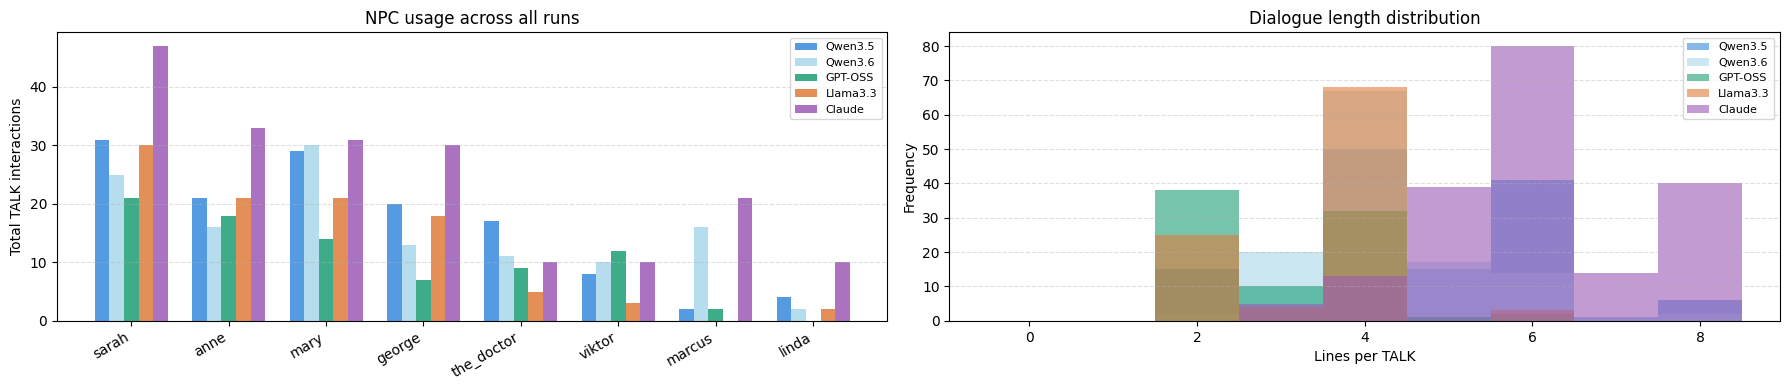

Saved → qualitative_npc_dialogue.png


In [12]:
all_npcs = ['sarah', 'anne', 'mary', 'george', 'the_doctor', 'viktor', 'marcus', 'linda']

model_labels = {
    "Qwen3.5-122B":    "Qwen3.5",
    "Qwen3.6-27B":     "Qwen3.6",
    "GPT-OSS-120B":    "GPT-OSS",
    "Llama3.3-70B":    "Llama3.3",
    "claude-opus-4-7": "Claude",
}

def normalise_target(t):
    return t.replace(' ', '_')

all_model_talks = [
    (model_id, get_talk_steps(data))
    for model_id, data in all_model_data.items()
]

npc_counts = {
    model_id: [
        collections.Counter(normalise_target(t['target']) for t in talks if t['target']).get(npc, 0)
        for npc in all_npcs
    ]
    for model_id, talks in all_model_talks
}

n = len(all_model_talks)
x = np.arange(len(all_npcs))
width = 0.15
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

ax = axes[0]
for i, (model_id, _) in enumerate(all_model_talks):
    offset = (i - (n - 1) / 2) * width
    ax.bar(x + offset, npc_counts[model_id], width, label=model_labels.get(model_id, model_id), color=COLORS[model_id], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(all_npcs, rotation=30, ha='right')
ax.set_ylabel("Total TALK interactions")
ax.set_title("NPC usage across all runs")
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax = axes[1]
bins = range(0, 10)
for model_id, talks in all_model_talks:
    lengths = [t['n_lines'] for t in talks]
    ax.hist(lengths, bins=bins, alpha=0.6, color=COLORS[model_id], label=model_labels.get(model_id, model_id), align='left')
ax.set_xlabel("Lines per TALK")
ax.set_ylabel("Frequency")
ax.set_title("Dialogue length distribution")
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("qualitative_npc_dialogue.png", dpi=150)
plt.show()
print("Saved → qualitative_npc_dialogue.png")

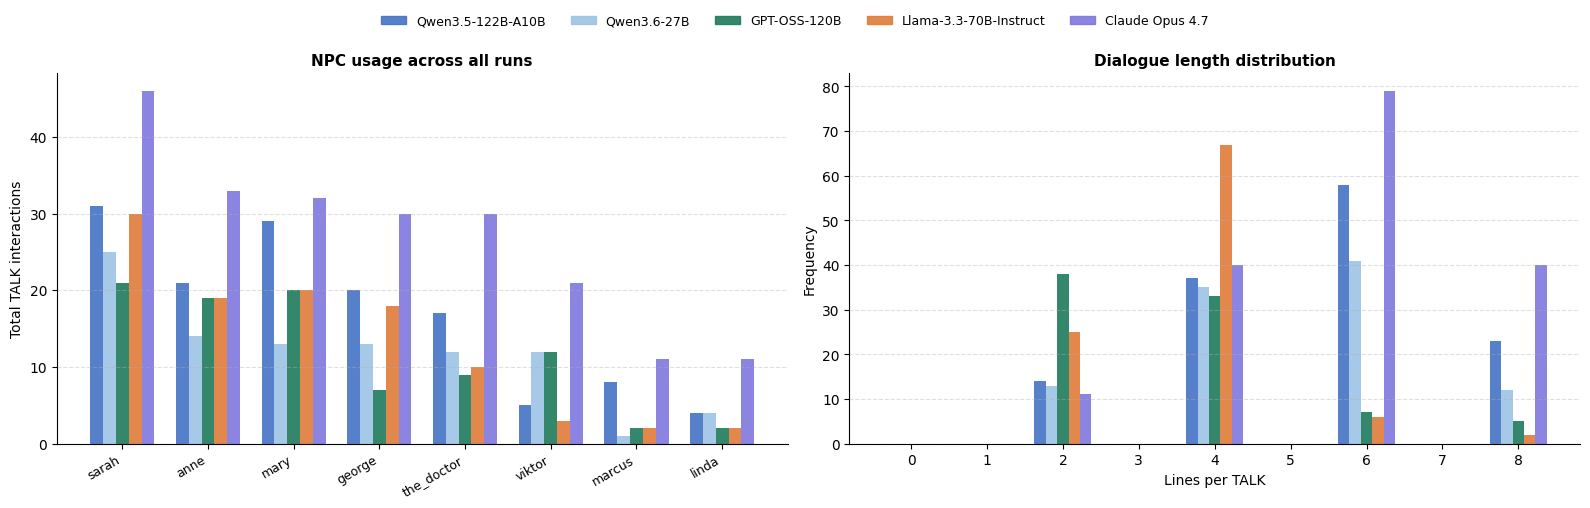

In [13]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Qwen3.5-122B-A10B', 'Qwen3.6-27B', 'GPT-OSS-120B', 'Llama-3.3-70B-Instruct', 'Claude Opus 4.7']
colors = ['#4472C4', '#9DC3E6', '#1F7A5C', '#E07B39', '#7F77DD']

npcs = ['sarah', 'anne', 'mary', 'george', 'the_doctor', 'viktor', 'marcus', 'linda']
npc_data = {
    'Qwen3.5-122B-A10B':      [31, 21, 29, 20, 17,  5,  8,  4],
    'Qwen3.6-27B':            [25, 14, 13, 13, 12, 12,  1,  4],
    'GPT-OSS-120B':           [21, 19, 20,  7,  9, 12,  2,  2],
    'Llama-3.3-70B-Instruct': [30, 19, 20, 18, 10,  3,  2,  2],
    'Claude Opus 4.7':        [46, 33, 32, 30, 30, 21, 11, 11],
}

dl_data = {
    'Qwen3.5-122B-A10B':      [0, 0, 14, 0, 37, 0, 58, 0, 23],
    'Qwen3.6-27B':            [0, 0, 13, 0, 35, 0, 41, 0, 12],
    'GPT-OSS-120B':           [0, 0, 38, 0, 33, 0,  7, 0,  5],
    'Llama-3.3-70B-Instruct': [0, 0, 25, 0, 67, 0,  6, 0,  2],
    'Claude Opus 4.7':        [0, 0, 11, 0, 40, 0, 79, 0, 40],
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='white')
n = len(models)
width = 0.15

# NPC usage chart
ax = axes[0]
x = np.arange(len(npcs))
for i, (model, color) in enumerate(zip(models, colors)):
    offset = (i - n/2 + 0.5) * width
    ax.bar(x + offset, npc_data[model], width, label=model, color=color, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(npcs, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Total TALK interactions', fontsize=10)
ax.set_title('NPC usage across all runs', fontsize=11, fontweight='bold')
ax.set_facecolor('white')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Dialogue length distribution
ax = axes[1]
dl_labels = list(range(9))
for i, (model, color) in enumerate(zip(models, colors)):
    offset = (i - n/2 + 0.5) * width
    ax.bar([x + offset for x in dl_labels], dl_data[model], width, label=model, color=color, alpha=0.9)
ax.set_xlabel('Lines per TALK', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.set_title('Dialogue length distribution', fontsize=11, fontweight='bold')
ax.set_xticks(dl_labels)
ax.set_facecolor('white')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Shared legend at top
handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.9) for c in colors]
fig.legend(handles, models, loc='upper center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, 1.02), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Dialogue_and_characters.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Better visual for the paper. 

# TITLE VARIETY PER CHAPTER

In [14]:
for model_id, data in all_model_data.items():
    print(f"=== {model_id} ===")
    for ch in ["C1", "C2", "C3"]:
        titles  = [e['quest_data'].get('chapter_title', '')
                   for e in data if e['chapter_id'] == ch]
        counter = collections.Counter(titles)
        unique  = len(counter)
        top3    = counter.most_common(3)
        print(f"  {ch} — {unique}/{len(titles)} unique titles")
        for title, count in top3:
            print(f"    '{title}' × {count}")
    print()

=== Qwen3.5-122B ===
  C1 — 4/10 unique titles
    'The Spark and the Sample' × 3
    'The First Spark' × 3
    'The Spark in the Dark' × 2
  C2 — 4/10 unique titles
    'The Puppeteer's Shadow' × 7
    'The Shadow Behind the Mask' × 1
    'Shadows of the Outpost' × 1
  C3 — 3/10 unique titles
    'The Last Departure' × 6
    'The Final Departure' × 3
    'The Final Voyage' × 1

=== Qwen3.6-27B ===
  C1 — 4/10 unique titles
    'The First Spark' × 7
    'The Spark of Hope' × 1
    'The Last Spark' × 1
  C2 — 5/10 unique titles
    'The Puppeteer's Strings' × 6
    'Shadows of Control' × 1
    'The Architect of Ruin' × 1
  C3 — 4/10 unique titles
    'The Last Horizon' × 5
    'The Final Horizon' × 2
    'Departure' × 2

=== GPT-OSS-120B ===
  C1 — 4/10 unique titles
    'A Flicker of Hope' × 7
    'A Hope for the Dying Village' × 1
    'A Hopeful Cure' × 1
  C2 — 5/10 unique titles
    'Strings of the Shadow' × 6
    'Strings of Control' × 1
    'Unmasking the Puppeteer' × 1
  C3 — 6/1

# QUALITATIVE SUMMARY TABLE

In [15]:
def model_qualitative(data):
    talks = get_talk_steps(data)
    ct, qt = get_titles(data)
    return {"talks": talks, "ct": ct, "qt": qt}

stats = {model_id: model_qualitative(data) for model_id, data in all_model_data.items()}

def make_rows(model_id):
    t    = stats[model_id]["talks"]
    ct   = stats[model_id]["ct"]
    qt   = stats[model_id]["qt"]
    data = all_model_data[model_id]
    return [
        len(t),
        sum(x['n_lines'] for x in t),
        round(statistics.mean([x['n_lines'] for x in t]), 2) if t else 0,
        max((x['n_lines'] for x in t), default=0),
        len(set(ct)),
        len(set(qt)),
        len(qt),
        len(set(normalise_target(x['target']) for x in t if x['target'])),
        len(set(e['quest_data'].get('chapter_title', '') for e in data if e['chapter_id'] == 'C1')),
    ]

model_ids = list(all_model_data.keys())
first_ct_len = len(stats[model_ids[0]]["ct"])

labels = [
    "Total TALK steps",
    "Total dialogue lines",
    "Avg lines per TALK",
    "Max lines in one TALK",
    f"Unique chapter titles (of {first_ct_len})",
    "Unique quest titles",
    "Total quest titles",
    "NPCs used (of 8)",
    "C1 unique chapter titles",
]

col_w = 16
header = f"{'Metric':<35}" + "".join(f"{m:>{col_w}}" for m in model_ids)
print(header)
print("-" * (35 + col_w * len(model_ids)))
for i, label in enumerate(labels):
    row = f"{label:<35}"
    for model_id in model_ids:
        row += f"{str(make_rows(model_id)[i]):>{col_w}}"
    print(row)

Metric                                 Qwen3.5-122B     Qwen3.6-27B    GPT-OSS-120B    Llama3.3-70B claude-opus-4-7
-------------------------------------------------------------------------------------------------------------------
Total TALK steps                                132             123              83             100             192
Total dialogue lines                            618             524             251             352            1172
Avg lines per TALK                             4.68            4.26            3.02            3.52             6.1
Max lines in one TALK                             8               8               6               6              10
Unique chapter titles (of 30)                    11              13              15              12              13
Unique quest titles                              95              50              48              36              82
Total quest titles                              116              72     

In [16]:
error_metrics = [
    "scale_mismatch", "locked_move", "hallucinated_npcs", "invalid_actions",
    "move_noop", "pickup_no_move", "synth_no_sample", "repair_no_toolkit",
    "repair_no_wood", "use_cure_no_synth", "quest_no_talk", "duplicate_talk"
]

SHORT = {
    "Qwen3.5-122B":    "Qwen3.5",
    "Qwen3.6-27B":     "Qwen3.6",
    "GPT-OSS-120B":    "GPT-OSS",
    "Llama3.3-70B":    "Llama3.3",
    "claude-opus-4-7": "Claude",
}

models = detail['model'].unique().tolist()
col_w  = 12

header = f"{'Metric':<30}" + "".join(f"{SHORT.get(m, m):>{col_w}}" for m in models)
print(header)
print("-" * (30 + col_w * len(models)))

for col in error_metrics:
    row = f"{col:<30}"
    for model in models:
        model_rows  = detail[detail['model'] == model]
        total_errors = model_rows[col].sum()
        total_quests = model_rows['num_quests'].sum()
        rate = round(total_errors / total_quests, 3) if total_quests > 0 else 0
        row += f"{rate:>{col_w}}"
    print(row)

print()
print(f"{'total quests generated':<30}", end="")
for model in models:
    total = detail[detail['model'] == model]['num_quests'].sum()
    print(f"{total:>{col_w}}", end="")
print()

Metric                             Qwen3.5     Qwen3.6     GPT-OSS    Llama3.3      Claude
------------------------------------------------------------------------------------------
scale_mismatch                       0.103        0.19        0.37       0.253       0.016
locked_move                          0.198       0.048       0.111       0.228         0.0
hallucinated_npcs                      0.0         0.0       0.796         0.0         0.0
invalid_actions                        0.0         0.0       0.019         0.0         0.0
move_noop                              0.0       0.048       0.111       0.114       0.024
pickup_no_move                        0.06       0.027       0.019       0.038       0.016
synth_no_sample                      0.009       0.014         0.0       0.013         0.0
repair_no_toolkit                    0.009       0.007       0.019         0.0       0.008
repair_no_wood                       0.009         0.0         0.0         0.0         0.0

# Statistical analysis

In [17]:
from scipy import stats
import scikit_posthocs as sp

# Metrics to test
metrics = numeric_cols

# Model order
models = ['Qwen3.5-122B', 'Qwen3.6-27B', 'GPT-OSS-120B', 'Llama3.3-70B', 'claude-opus-4-7']

print("=== Kruskal-Wallis + Dunn Post-hoc Tests ===\n")

for metric in metrics:
    print(f"--- {metric} ---")
    
    # Get data per model (all 30 runs)
    groups = [detail[detail['model'] == m][metric].values for m in models]
    
    # Skip if all values are identical
    all_values = [v for g in groups for v in g]
    if len(set(all_values)) == 1:
        print(f"Skipped — all values identical ({all_values[0]})")
        print()
        continue
    
    # Kruskal-Wallis
    try:
        H, p = stats.kruskal(*groups)
    except ValueError:
        print("Skipped — all values identical")
        print()
        continue
    
    print(f"H = {H:.3f}, p = {p:.4f}")
    
    if p < 0.05:
        print("Significant — running Dunn's post-hoc with Holm correction...")
        dunn = sp.posthoc_dunn(
            detail, val_col=metric, group_col='model', p_adjust='holm'
        )
        print(dunn)
        print("Significant pairs (p < 0.05):")
        for i, m1 in enumerate(models):
            for j, m2 in enumerate(models):
                if j > i:
                    pval = dunn.loc[m1, m2]
                    if pval < 0.05:
                        print(f"  {m1} vs {m2}: p = {pval:.4f}")
    else:
        print("Not significant — no post-hoc needed.")
    print()
    
    # Epsilon-squared effect size for Kruskal-Wallis
# Formula: ε² = (H - k + 1) / (n - k)
# where k = number of groups, n = total observations

k = len(models)  # 5
n_total = k * 30  # 150

print("=== Epsilon-squared effect sizes ===\n")

for metric in metrics:
    groups = [detail[detail['model'] == m][metric].values for m in models]
    all_values = [v for g in groups for v in g]
    
    if len(set(all_values)) == 1:
        print(f"{metric}: — (identical values)")
        continue
    
    try:
        H, p = stats.kruskal(*groups)
        epsilon_sq = (H - k + 1) / (n_total - k)
        print(f"{metric}: H = {H:.3f}, p = {p:.4f}, ε² = {epsilon_sq:.3f}")
    except ValueError:
        print(f"{metric}: — (identical values)")

=== Kruskal-Wallis + Dunn Post-hoc Tests ===

--- json_parse_success ---
Skipped — all values identical (1)

--- attempts ---
H = 15.791, p = 0.0033
Significant — running Dunn's post-hoc with Holm correction...
                 GPT-OSS-120B  Llama3.3-70B  Qwen3.5-122B  Qwen3.6-27B  \
GPT-OSS-120B         1.000000      0.015323      1.000000      1.00000   
Llama3.3-70B         0.015323      1.000000      0.015323      0.00291   
Qwen3.5-122B         1.000000      0.015323      1.000000      1.00000   
Qwen3.6-27B          1.000000      0.002910      1.000000      1.00000   
claude-opus-4-7      1.000000      0.128355      1.000000      1.00000   

                 claude-opus-4-7  
GPT-OSS-120B            1.000000  
Llama3.3-70B            0.128355  
Qwen3.5-122B            1.000000  
Qwen3.6-27B             1.000000  
claude-opus-4-7         1.000000  
Significant pairs (p < 0.05):
  Qwen3.5-122B vs Llama3.3-70B: p = 0.0153
  Qwen3.6-27B vs Llama3.3-70B: p = 0.0029
  GPT-OSS-120B vs L

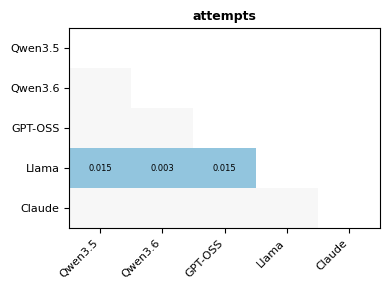

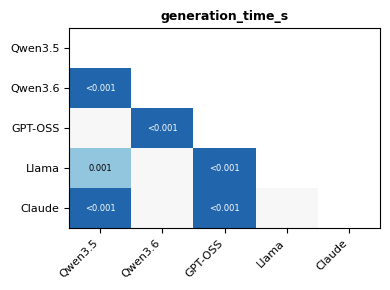

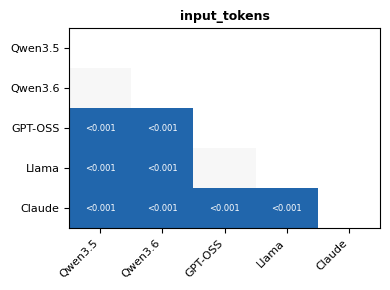

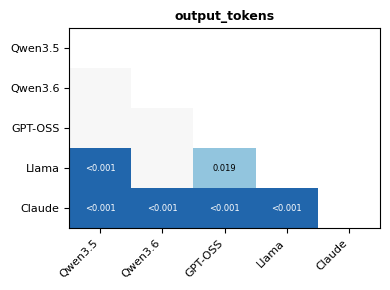

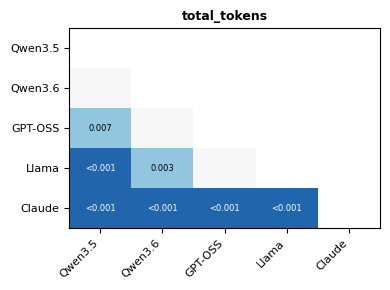

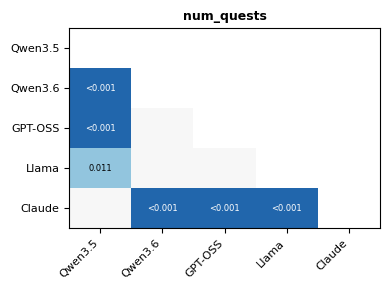

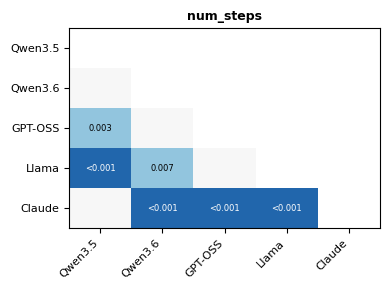

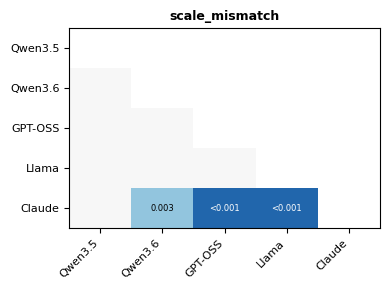

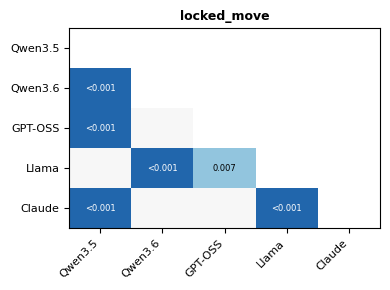

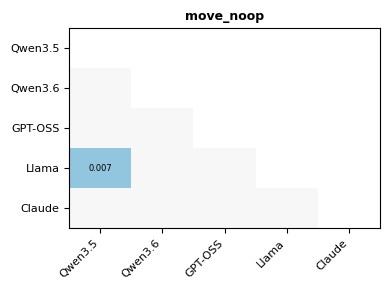

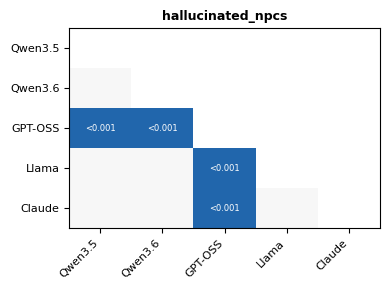

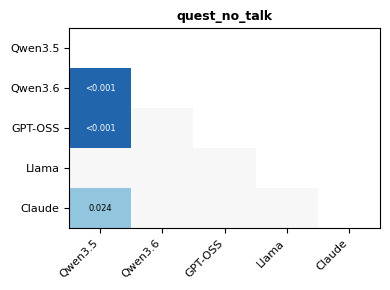

In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_dunn_heatmap(dunn, metric, models):
    short_names = {
        'Qwen3.5-122B': 'Qwen3.5',
        'Qwen3.6-27B': 'Qwen3.6', 
        'GPT-OSS-120B': 'GPT-OSS',
        'Llama3.3-70B': 'Llama',
        'claude-opus-4-7': 'Claude'
    }
    labels = [short_names.get(m, m) for m in models]
    
    n = len(models)
    matrix = np.ones((n, n))
    
    for i, m1 in enumerate(models):
        for j, m2 in enumerate(models):
            if i != j:
                matrix[i, j] = dunn.loc[m1, m2]
    
    mask = np.triu(np.ones((n, n), dtype=bool))
    matrix_masked = np.ma.array(matrix, mask=mask)
    
    fig, ax = plt.subplots(figsize=(4, 3))
    
    cmap = mcolors.ListedColormap(['#2166ac', '#92c5de', '#f7f7f7'])
    bounds = [0, 0.001, 0.05, 1.01]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    ax.imshow(matrix_masked, cmap=cmap, norm=norm, aspect='auto')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    
    for i in range(n):
        for j in range(n):
            if j < i:
                val = matrix[i, j]
                txt = '<0.001' if val < 0.001 else f'{val:.3f}' if val < 0.05 else ''
                ax.text(j, i, txt, ha='center', va='center', fontsize=6,
                       color='white' if val < 0.001 else 'black')
    
    ax.set_title(metric, fontsize=9, fontweight='bold')
    plt.tight_layout()
    return fig

for metric in metrics:
    groups = [detail[detail['model'] == m][metric].values for m in models]
    all_values = [v for g in groups for v in g]
    
    if len(set(all_values)) == 1:
        continue
    
    try:
        H, p = stats.kruskal(*groups)
    except ValueError:
        continue
    
    if p < 0.05:
        dunn = sp.posthoc_dunn(
            detail, val_col=metric, group_col='model', p_adjust='holm'
        )
        fig = plot_dunn_heatmap(dunn, metric, models)
        plt.show()
        plt.close()

## Findings Summary (Five Model Evaluation)

> This notebook evaluates five models: Qwen3.5-122B, Qwen3.6-27B, GPT-OSS-120B, Llama3.3-70B, and claude-opus-4-7.
> Both the normalise_step fix and the locked_move state tracking fix were applied before this run.
> The antidote_1 naming fix was also applied to ensure consistent world state chaining across all models.
> Qwen3.6 was re-evaluated on the main server to ensure all five models are compared under the same conditions.

---

### Quantitative

#### Structural validity
Measures whether the output conforms to the expected format and scale.

- json_parse_success: 100% for Qwen3.5, Qwen3.6, GPT-OSS, Llama3.3 and Claude.
- num_quests: Qwen3.5 averages 3.9 per chapter. Claude averages 4.2. Qwen3.6 averages 2.5. Llama3.3 averages 2.6. GPT-OSS averages 1.8. Claude and Qwen3.5 generate the most sub-quests by a significant margin.
- num_steps: Claude averages 27.4 steps (±7.3). Qwen3.5 averages 24.4 (±10.7). Qwen3.6 averages 20.0 (±11.4). GPT-OSS averages 16.3 (±5.8). Llama3.3 averages 14.2 (±4.8). Claude generates the most steps on average with relatively lower variance than Qwen3.5.
- scale_mismatch: Claude 0.067. Qwen3.5 0.4. Qwen3.6 0.467. Llama3.3 0.667. GPT-OSS 0.667. Claude most reliably hits the target scale by a large margin.

#### Action validity
Measures whether actions are legal and correctly formed.

- invalid_actions: 0 for all models except GPT-OSS (0.033). Near-zero across all models.
- actor_not_player: 0 for all models across all runs.
- missing_parameters: 0 for all models.
- unknown_parameters: Qwen3.6 1.067 per chapter (±4.456). Claude 0.067. All other models 0. The high stdev for Qwen3.6 indicates rare but severe bursts rather than a consistent pattern. Claude's single instance is isolated.

#### World state consistency
Measures whether steps respect the current state of the world.

- move_noop: Qwen3.5 0. Qwen3.6 0.117. GPT-OSS 0.2. Llama3.3 0.3. Claude 0.1. All near-zero.
- hallucinated_locations: 0 for all models across all runs.
- hallucinated_npcs: GPT-OSS 1.433 (±1.547). All other models including Claude 0. GPT-OSS remains the only model that invents character names.
- hallucinated_items: 0 for all models across all runs.
- locked_move: Qwen3.5 0.767 (±0.817). Llama3.3 0.6 (±0.563). GPT-OSS 0.2 (±0.407). Qwen3.6 0.133 (±0.343). Claude 0.0. Claude is the only model with zero locked_move violations across all runs. Looking more closely at the violations in the other four models, they fall into two distinct types. Type 1 (MOVE planned before UNLOCK in the same chapter): Llama3.3 100%, GPT-OSS 100%, Qwen3.6 100%, Qwen3.5 70%. Type 2 (no UNLOCK planned at all): Qwen3.5 30%. Llama3.3, GPT-OSS, and Qwen3.6 exclusively missequence steps; Qwen3.5 is the only model that also ignores the locked condition entirely.

#### Inventory consistency
Measures whether the model correctly tracks what the player is carrying.

- pickup_no_move: Qwen3.5 0.233. Qwen3.6 0.067. Llama3.3 0.1. Claude 0.067. GPT-OSS 0.033. All near-zero.
- synth_no_sample: Qwen3.5 0.033. Qwen3.6 0.033. Llama3.3 0.033. Claude 0. GPT-OSS 0. All near-zero.
- repair_no_toolkit: Qwen3.5 0.033. GPT-OSS 0.033. Claude 0.033. Qwen3.6 0.017. All near-zero.
- repair_no_wood: Qwen3.5 0.033. All others 0.
- use_cure_no_synth: Qwen3.6 0.067. Llama3.3 0.033. All others 0.

#### Narrative coherence
Measures whether the quest makes sense as a story.

- quest_no_talk: Qwen3.5 0.7. Llama3.3 0.233. Claude 0.2. Qwen3.6 0.083. GPT-OSS 0. Qwen3.5 generates the most quests with zero NPC interaction by a large margin. GPT-OSS never does. Claude sits in the middle. Qwen3.6 is the best performing local model on this metric.
- duplicate_talk: Qwen3.6 0.017. All other models 0.

#### Performance
Measures how efficiently the model produced the output.

- generation_time_s: GPT-OSS fastest at 14.0s (±3.5). Qwen3.5 20.6s (±7.3). Llama3.3 45.9s (±27.6). Qwen3.6 53.0s (±27.5). Claude 53.9s (±8.6). Qwen3.6 and Claude are the slowest and nearly identical in mean time, though Claude is notably more consistent. Notably, Qwen3.5-122B is faster than Qwen3.6-27B despite having far more total parameters. This is because Qwen3.5-122B is a Mixture of Experts model (official name Qwen3.5-122B-A10B) that activates only 10B parameters per forward pass, while Qwen3.6-27B is a fully dense model that activates all 27B parameters for every token.
- output_tokens: Claude 3,832 (±1,030). Qwen3.5 2,555 (±922). GPT-OSS 2,229 (±561). Qwen3.6 1,952 (±968). Llama3.3 1,478 (±850). Claude generates substantially more output tokens than any other model.
- attempts: Llama3.3 1.167 (±0.461). Claude 1.1 (±0.403). All other models 1.0. Both occasionally require a retry but always succeed within 3 attempts.

---

### Qualitative — Measurable

These observations are directly supported by the data and do not require subjective judgment.

#### Dialogue volume
- Total TALK steps: Claude (190), Qwen3.5 (132), Qwen3.6 (123), Llama3.3 (100), GPT-OSS (83). Claude generates by far the most dialogue interactions.
- Total dialogue lines: Claude (1159), Qwen3.5 (618), Qwen3.6 (524), Llama3.3 (352), GPT-OSS (251). Claude produces nearly double the dialogue lines of Qwen3.5.
- Avg lines per TALK: Claude (6.10), Qwen3.5 (4.68), Qwen3.6 (4.26), Llama3.3 (3.52), GPT-OSS (3.02). Claude consistently produces the longest individual exchanges.
- Max lines in one TALK: Claude reaches 9. Qwen3.5 and Qwen3.6 reach 8. GPT-OSS and Llama3.3 cap at 6.

#### Variety across runs
- Unique chapter titles: GPT-OSS (15/30), Qwen3.6 (13/30), Llama3.3 (12/30), Qwen3.5 (11/30), Claude (11/29). Claude and Qwen3.5 show the least chapter title variety despite generating the most content overall.
- Unique quest titles: Qwen3.5 (95/116), Claude (82/125), Qwen3.6 (50/72), GPT-OSS (48/54), Llama3.3 (36/79). Llama3.3 has the lowest proportion of unique quest titles. Claude generates the most quest titles in total but maintains reasonable variety.
- C1 unique chapter titles: Llama3.3 (9/10) most varied. Qwen3.5, Qwen3.6, and GPT-OSS all at 4/10. Claude (7/9) is the most varied among models with meaningful content volume.
- Llama3.3 C3 title is identical across all 10 runs ("Escape from the Island"). Llama3.3 C2 uses the same title in 6 of 10 runs ("Unraveling the Mystery"). Claude C3 is also identical across all 10 runs ("The Last Tide") and C2 repeats in 8 of 10 runs ("The Hand Behind the Curtain").

#### NPC coverage
- NPCs used: Qwen3.5, Qwen3.6, and Claude use all 8. GPT-OSS and Llama3.3 use 7. Linda does not appear in GPT-OSS or Llama3.3 runs.
- The Qwen models and Claude use all 8 NPCs. Claude gives the most interactions to every character compared to the other models.
- Viktor is largely sidelined in Llama3.3 (3 interactions across 30 chapters) despite being the primary antagonist. Llama3.3 also barely uses the_doctor (5 interactions).

---

### Qualitative — Subjective human review

The following observations are based on reading actual quest output and dialogue from the generated JSON files. These are subjective assessments based on a single reviewer reading selected outputs and should not be treated as objective conclusions.

#### Dialogue character and tone
- Qwen3.5 produces the most character-driven dialogue of the four local models. Characters have distinct voices that appear consistently across runs. Anne speaks in cautious layered warnings. The Doctor is detached and clinical. Viktor is commanding and dismissive. Exchanges have subtext beyond the immediate quest objective.
- Qwen3.6 produces noticeably similar character voices to Qwen3.5 despite being a smaller model. Viktor confrontations feel appropriately hostile and the Doctor speaks with ideological detachment. Dialogue is slightly shorter on average but maintains individual character identity. A strong result for a fully dense 27B model.
- GPT-OSS produces shorter, more functional exchanges. Characters convey the necessary quest information efficiently but with less tonal variation between NPCs.
- Llama3.3 produces the most generic dialogue of the local models. Exchanges follow a simple question-answer pattern with little character voice. Anne gives quest directions without personality. George and Sarah are almost interchangeable in tone. The Doctor and Viktor do not appear in the sampled C2/C3 outputs despite the story reaching the antagonist phase, suggesting Llama3.3 avoids confrontational dialogue entirely.
- Claude produces the longest and most varied exchanges. Dialogue includes emotional subtext, character-specific speech patterns, and reactions that go beyond the immediate quest objective. Claude makes every character appear more frequently and with more defined personalities than in any other model. The higher output token count is largely driven by dialogue volume rather than structural verbosity.

#### Quest creativity and variety
- Qwen3.5 occasionally deviates from the most obvious solution path with investigation steps and alternative approaches. Observed in a minority of runs and not consistent.
- Qwen3.6 follows a more structured path than Qwen3.5 but maintains reasonable variety in how it frames quests and which NPCs it involves in each chapter.
- GPT-OSS follows a predictable structure particularly in C1. C2 and C3 show slightly more variation.
- Llama3.3 is the most structurally repetitive of the local models. C3 is identical across all 10 runs and C2 uses the same chapter title in 6 of 10 runs. Quest arcs are logically coherent but feel templated rather than generated.
- Claude generates the most sub-quests per chapter and the most steps overall, but chapter title variety is low for C2 and C3, with C3 identical across all runs. This suggests Claude produces more content within a narrower set of narrative framings than the local models.

#### Overall impression
- Qwen3.5 generates the most content among the local models with the most variety but also the most rule violations.
- Qwen3.6 is a strong fully dense 27B model with comparable dialogue quality to Qwen3.5 but less content overall and slower generation due to activating all parameters per token.
- GPT-OSS generates the least dialogue and is the most structurally predictable but the fastest and most reliable. Its hallucinated NPCs issue is the main ongoing weakness.
- Llama3.3 is consistent but produces the least creative output. The identical C3 across all runs and near-absence of the Doctor and Viktor from outputs suggests it defaults to safe repetitive story patterns.
- Claude is the strongest overall performer on rule compliance, with zero locked_move violations, the lowest scale_mismatch, and zero hallucinated NPCs, while simultaneously generating the most dialogue and the most steps. The trade-off is the highest token cost and slowest generation time alongside Qwen3.6.

---

### Statistical Analysis

Kruskal-Wallis tests were run on all metrics to assess whether observed differences between models are statistically significant. All 30 observations per model were used with the three chapters pooled. The three chapters within a run are not independent since the evaluation script feeds the updated world state from one chapter to the next — treating the 30 pooled values as fully independent overstates the real amount of information. Results should be treated as exploratory. Multiple comparisons were corrected within each post-hoc test using Holm correction.

Significant results (p < 0.001) were found for: number of quests (H=59.68, ε²=0.384), number of steps (H=55.97, ε²=0.358), scale mismatch (H=29.31, ε²=0.175), locked move violation (H=50.60, ε²=0.321), hallucinated NPCs (H=87.10, ε²=0.573), quest without dialogue (H=24.23, ε²=0.139), and all performance metrics. Action validity and inventory consistency metrics showed no significant differences, consistent with the near-zero values across all models.

Dunn's post-hoc tests identified the key pairs:
- **Locked move**: Claude < Qwen3.5 (p<0.001), Claude < Llama3.3 (p<0.001), Qwen3.6 < both (p<0.001)
- **Scale mismatch**: Claude differs from GPT-OSS (p<0.001), Llama3.3 (p<0.001), Qwen3.6 (p=0.003)
- **Quest without dialogue**: Qwen3.5 > GPT-OSS (p<0.001), Qwen3.6 (p<0.001), Claude (p=0.024)
- **Hallucinated NPCs**: GPT-OSS differs from all other models (p<0.001)
- **Generation time**: GPT-OSS faster than Qwen3.6, Llama3.3, Claude (all p<0.001); Qwen3.5 faster than Qwen3.6 (p<0.001), Llama3.3 (p=0.001), Claude (p<0.001)

---

### Core finding

Across five models, a consistent pattern emerges. Larger or more capable models generate more content but violate structural rules more often, with one exception. Claude generates the most content of any model while also producing the fewest rule violations, breaking the content-vs-compliance trade-off seen in the four local models.

**Qwen3.5-122B** is the strongest content generator among local models. Most quests, most dialogue, most NPC coverage, most variety. quest_no_talk (0.7) and locked_move (0.767) are its main genuine failures. Its speed advantage over Qwen3.6 is explained by its architecture: Qwen3.5-122B is a Mixture of Experts model that activates only 10B parameters per forward pass despite having 122B total parameters.

**Qwen3.6-27B** is the best rule follower among local models across most metrics. Lowest locked_move (0.133), lowest quest_no_talk (0.083), zero hallucinated NPCs. The trade-off is slower generation (53.0s per chapter) due to being a fully dense model that activates all 27B parameters, and lower content volume than Qwen3.5.

**GPT-OSS-120B** has zero quest_no_talk and the fastest generation time but is let down by hallucinated NPCs (1.433) and the highest scale_mismatch (0.667). It is reliable on some metrics and poor on others rather than consistently strong.

**Llama3.3-70B** falls between the extremes on most metrics but produces the lowest creative variety. C3 identical across all runs and near-absent antagonist characters make it the weakest candidate for a game that requires varied character-driven quests.

**claude-opus-4-7** is the strongest overall model. Zero locked_move violations, lowest scale_mismatch (0.067), zero hallucinated NPCs, highest dialogue volume, and most balanced NPC coverage. The main costs are token usage (3,832 output tokens per chapter vs 1,478-2,555 for local models) and generation time (53.9s). For a use case where quality matters more than cost, Claude is the clear leader. For a cost-constrained or latency-sensitive context, Qwen3.5 or Qwen3.6 are the strongest local alternatives.

---